<a href="https://colab.research.google.com/github/tsat4pd3-sketch/OEE/blob/main/train_obj_detect.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Install Libraries

In [8]:
!pip install ultralytics

# Import Libraries

In [ ]:
from ultralytics import YOLO
from IPython.display import Image,display

In [9]:
!nvidia-smi

Tue Mar 24 02:38:34 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   66C    P0             31W /   70W |     259MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

# Connect Drive

In [10]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**Download YOLO Classification Pre-Train**

In [ ]:
model = YOLO("yolo26n.pt")

In [13]:
# ก๊อปปี้จาก Drive มาที่ Colab (สร้างมาใส่อีกล่องด้านซ้ายมือเนี่ย ไม่ใช่ path Google drive)
!cp -r "/content/drive/MyDrive/IIOT/AI_YOLO/Dataset/nut_bolt_obj_detect" /content/nut_bolt_obj_detect

**Transfer Learning Training**

In [20]:
# data ให้ copy path จากอีกล่องด้านซ้ายมือเนี่ย มาวาง ส่วน project คือ path ใน google drive ที่จะไปเก็บ
results = model.train(data="/content/nut_bolt_obj_detect/data.yaml" , project="/content/drive/MyDrive/IIOT/AI_TEST", name='nut_bolt' , epochs=50, imgsz=640, batch=4, device="cuda" ,
                      degrees=30, scale=0.5, shear=10, hsv_h=0.05, hsv_s=0.9, hsv_v=0.6)

# Test: ทดสอบกับชุดข้อมูลใหม่ (Test Set) ที่แยกไว้
test_metrics = model.val(split='test', project='/content/drive/MyDrive/IIOT/AI_TEST' , name='nut_bolt_test')

Ultralytics 8.4.26 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/nut_bolt_obj_detect/data.yaml, degrees=30, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.05, hsv_s=0.9, hsv_v=0.6, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=nut_bolt7, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, pers

### **Test model**

# Use Model

**Load Model File**

In [ ]:
# เปลี่ยนเป็นเส้นทาง (Path) ใน Google Drive ของตนเอง

model = YOLO('...')  # อัปโหลดโมเดล

**User Test**

Saving capture_11.jpg to capture_11.jpg

image 1/1 /content/capture_11.jpg: 480x640 2 bolts, 2 nuts, 58.1ms
Speed: 2.0ms preprocess, 58.1ms inference, 0.5ms postprocess per image at shape (1, 3, 480, 640)


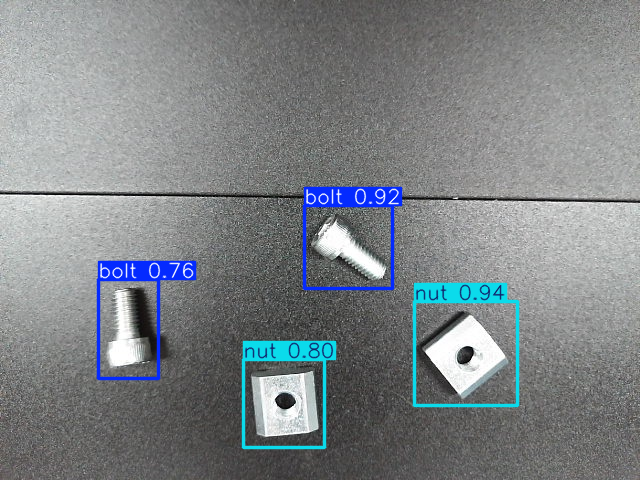

Do you want to classify another file? (y/n): n


In [ ]:
from google.colab import files

# ลูปเลือกภาพทดสอบ
while True:
    uploaded = files.upload() # อัปโหลดไฟล์รูป

    if not uploaded: # ถ้ากดยกเลิก
        print("No file selected. Exiting...")
        break

    for file_name in uploaded.keys(): # ถ้าเลือกไฟล์ถูกประเภท
        file_path = file_name # ค้นหาไฟล์ที่เลือก

        try:

          results = model(file_path, conf=0.3 , iou=0.5)  # เรียกใช้ฟังชั่น classify_image แล้วส่ง file_path(ตำแหน่ง) ของไฟล์ภาพ
          results[0].show()

        except Exception as e: # ถ้าเลือกไฟล์ผิดประเภท
              print("Error occurred:", e)
              print("Please make sure the file path is correct and the Image format is supported.")

    another = input("Do you want to classify another file? (y/n): ")  # ถามว่าจะทำนายต่อไหม
    if another.lower() != 'y': # ถ้าพิมพ์ไม่เท่ากับ y จะหยุดทำงาน
        break